In [1]:

import os
import warnings
warnings.filterwarnings("ignore")

from IPython.display import HTML


# Data Handling

import numpy as np
import pandas as pd
import shutil


# Visualization

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
import seaborn as sns


# PyTorch Libraries

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.models as models
import torchvision.transforms as transforms

from torch.utils.data import (
    DataLoader,
    TensorDataset,
    Dataset,
    default_collate
)


# Machine Learning Utilities

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)


# Image Processing

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


# Progress Bar

from tqdm.auto import tqdm


# Device Configuration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:

# Color Palette Configuration


color_list = [
    '#faa5c7',
    '#eb679c',
    '#cc3d76',
    '#b3245d',
    '#d40457',
    '#8f1042',
    '#6e042e'
]

# Create seaborn palette
color_palette = sns.color_palette(color_list)
sns.set_palette(color_palette)

# Create matplotlib colormap
cmap = LinearSegmentedColormap.from_list(
    'custom_palette',
    color_list,
    N=256
)

# Ignore warnings
warnings.filterwarnings("ignore")

In [4]:

# Remove Corrupted Images


def remove_corrupt_files(directory_path):

    for item in os.listdir(directory_path):

        item_path = os.path.join(directory_path, item)

        # If item is a directory → go inside it
        if os.path.isdir(item_path):
            remove_corrupt_files(item_path)

        else:
            try:
                img = Image.open(item_path)
                img.verify()   # check image integrity

            except (IOError, SyntaxError, OSError):
                os.remove(item_path)
                print(f"Removed corrupted image: {item_path}")

print("Corrupt image removal function loaded.")

Corrupt image removal function loaded.


In [13]:

# Copy Dataset to Working Directory


def copy_dataset_into_working_dir(source_directory, destination_directory):

    # Remove destination if already exists
    if os.path.exists(destination_directory):
        print("Removing old dataset directory...")
        shutil.rmtree(destination_directory)

    # Copy dataset
    print("Copying dataset to working directory...")
    shutil.copytree(source_directory, destination_directory)

    print("Dataset copy complete.")

In [14]:

# Dataset Directories


input_directory = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification"

output_directory = "/kaggle/working"

dataset_directory = f"{output_directory}/dataset"

output_train_directory = f"{dataset_directory}/Bone_Fracture_Binary_Classification/train"

output_dev_directory = f"{dataset_directory}/Bone_Fracture_Binary_Classification/val"

output_test_directory = f"{dataset_directory}/Bone_Fracture_Binary_Classification/test"

print("Input Directory:", input_directory)
print("Dataset Directory:", dataset_directory)

Input Directory: /kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification
Dataset Directory: /kaggle/working/dataset


In [16]:
from google.colab import files
uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [17]:
import zipfile
import os

zip_path = "dataset.zip"      # zip file ka naam
extract_path = "dataset"      # yahan extract hoga

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [18]:
os.listdir("dataset")

['dataset']

In [21]:
import os
os.listdir("dataset")

[]

In [22]:
import os
os.listdir()

['.config', 'dataset.zip', 'dataset', 'sample_data']

In [23]:
os.listdir("dataset")

[]

In [24]:
import zipfile

with zipfile.ZipFile("dataset.zip",'r') as zip_ref:
    zip_ref.extractall("dataset")

In [25]:
import os
os.listdir("dataset")

['dataset']

In [26]:
os.listdir("dataset/dataset")

['train', 'val', 'test']

In [27]:
import shutil
import os

for item in os.listdir("dataset/dataset"):
    shutil.move(f"dataset/dataset/{item}", "dataset/")

In [28]:
shutil.rmtree("dataset/dataset")

In [29]:
os.listdir("dataset")

['train', 'val', 'test']

In [30]:
train_dir = "dataset/train"
val_dir = "dataset/val"
test_dir = "dataset/test"

In [31]:
os.listdir("dataset/train")

['not fractured', 'fractured']

In [32]:
IMAGE_SIZE = 224
img_size = IMAGE_SIZE

print("Image size:", img_size)

Image size: 224


In [33]:
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),

    # Data Augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),

    # Optional augmentations (uncomment if needed)
    # transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
    # transforms.RandomRotation(degrees=(30, 70)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])


dev_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])


test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [35]:
train_dataset = torchvision.datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

dev_dataset = torchvision.datasets.ImageFolder(
    root=val_dir,
    transform=dev_transform
)

test_dataset = torchvision.datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)

print("Train images:", len(train_dataset))
print("Validation images:", len(dev_dataset))
print("Test images:", len(test_dataset))

Train images: 9246
Validation images: 829
Test images: 506


In [36]:
def my_collate(batch):
    """
    Removes corrupted samples from batch if any.
    """
    batch = [item for item in batch if item is not None]

    if len(batch) == 0:
        return None

    return default_collate(batch)

In [37]:
batch_size = 16

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=my_collate
)

dev_dataloader = DataLoader(
    dev_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=my_collate
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=my_collate
)

print("DataLoaders ready!")

DataLoaders ready!


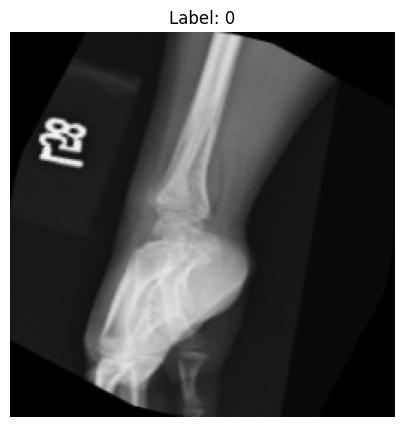

In [38]:
# Get one batch
x, y = next(iter(train_dataloader))

# Select an image from batch
img = x[4]

# Unnormalize image
img = img * 0.5 + 0.5

# Convert CHW -> HWC
img = img.permute(1, 2, 0)

# Plot image
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(f"Label: {y[4].item()}")
plt.axis("off")

plt.show()

In [39]:
class CNNBackbone(nn.Module):

    def __init__(self):

        super().__init__()

        resnet = models.resnet50(pretrained=True)

        self.features = nn.Sequential(*list(resnet.children())[:-1])

    def forward(self,x):

        x = self.features(x)

        x = torch.flatten(x,1)

        return x

In [40]:
model = CNNBackbone()

dummy = torch.randn(1,3,224,224)

output = model(dummy)

print(output.shape)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 210MB/s]


torch.Size([1, 2048])


In [41]:
class VisionMamba(nn.Module):

    def __init__(self):

        super().__init__()

        self.layer = nn.Sequential(
            nn.Linear(768,512),
            nn.ReLU(),
            nn.Linear(512,768)
        )

    def forward(self,x):

        return self.layer(x)

In [42]:
mamba = VisionMamba()

dummy = torch.randn(1,768)

output = mamba(dummy)

print(output.shape)

torch.Size([1, 768])


In [43]:
class ViTEncoder(nn.Module):

    def __init__(self):
        super(ViTEncoder, self).__init__()

        self.vit = torchvision.models.vit_b_16(pretrained=True)

        # remove classification head
        self.vit.heads = nn.Identity()

    def forward(self, x):
        x = self.vit(x)
        return x

In [44]:
class HybridModel(nn.Module):

    def __init__(self,num_classes):

        super().__init__()

        self.cnn = CNNBackbone()

        self.vit = ViTEncoder()

        self.mamba = VisionMamba()

        self.classifier = nn.Sequential(

            nn.Linear(2048+768,512),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(512,256),
            nn.ReLU(),

            nn.Linear(256,num_classes)
        )

    def forward(self,x):

        cnn_feat = self.cnn(x)

        vit_feat = self.vit(x)

        vit_feat = self.mamba(vit_feat)

        x = torch.cat([cnn_feat,vit_feat],dim=1)

        return self.classifier(x)

In [45]:
num_classes = len(train_dataset.classes)

model = HybridModel(num_classes).to(device)

print("Model Loaded")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:06<00:00, 56.8MB/s]


Model Loaded


In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [47]:
num_classes = len(train_dataset.classes)

model = HybridModel(num_classes).to(device)

print("Model Loaded")

Model Loaded


In [48]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

In [49]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

In [50]:
epochs = 10

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images,labels in train_dataloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _,predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted==labels).sum().item()

    scheduler.step()

    train_acc = 100*correct/total

    print(f"Epoch {epoch+1}/{epochs}")
    print("Loss:",running_loss)
    print("Train Accuracy:",train_acc,"%")

Epoch 1/10
Loss: 96.23533718613908
Train Accuracy: 93.29439757733074 %
Epoch 2/10
Loss: 30.428593116404954
Train Accuracy: 98.37767683322518 %
Epoch 3/10
Loss: 22.842476051933772
Train Accuracy: 98.63724853990915 %
Epoch 4/10
Loss: 11.977450894210051
Train Accuracy: 99.31862426995457 %
Epoch 5/10
Loss: 4.420911968592918
Train Accuracy: 99.70798182998053 %
Epoch 6/10
Loss: 3.6870417140692098
Train Accuracy: 99.79450573220852 %
Epoch 7/10
Loss: 0.30569864325482854
Train Accuracy: 99.978369024443 %
Epoch 8/10
Loss: 1.3251315865434705
Train Accuracy: 99.9026606099935 %
Epoch 9/10
Loss: 0.9438417329153026
Train Accuracy: 99.9675535366645 %
Epoch 10/10
Loss: 0.36580923402357257
Train Accuracy: 99.9891845122215 %


In [52]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in dev_dataloader:   # yaha change

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

print("Validation Accuracy:", 100 * correct / total, "%")

Validation Accuracy: 99.03498190591074 %


In [53]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in dev_dataloader:   # yaha change

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

print("Validation Accuracy:", 100 * correct / total, "%")

Validation Accuracy: 99.03498190591074 %


In [54]:
torch.save(model.state_dict(),"fracture_model.pth")

print("Model saved successfully")

Model saved successfully


In [56]:
import os
os.listdir()

['.config', 'dataset.zip', 'fracture_model.pth', 'dataset', 'sample_data']

In [57]:
import os

for root, dirs, files in os.walk("dataset"):
    for f in files:
        print(os.path.join(root, f))
        break
    break

In [58]:
import os

for root, dirs, files in os.walk("dataset"):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", files[:3])  # first 3 files
    print()

Folder: dataset
Subfolders: ['train', 'val', 'test']
Files: []

Folder: dataset/train
Subfolders: ['not fractured', 'fractured']
Files: []

Folder: dataset/train/not fractured
Subfolders: []
Files: ['35-rotated1-rotated3-rotated2.jpg', '3-rotated2 (1).jpg', '59-rotated3-rotated2-rotated1.jpg']

Folder: dataset/train/fractured
Subfolders: []
Files: ['3-rotated2 (1).jpg', '97-rotated1-rotated1 (1).jpg', '89-rotated1-rotated1-rotated3 - Copy.jpg']

Folder: dataset/val
Subfolders: ['not fractured', 'fractured']
Files: []

Folder: dataset/val/not fractured
Subfolders: []
Files: ['27-rotated1-rotated3-rotated1.jpg', '34-rotated3-rotated3-rotated3-rotated1.jpg', '29-rotated2-rotated1-rotated3.jpg']

Folder: dataset/val/fractured
Subfolders: []
Files: ['image02056.jpeg', 'ol-11-01-0439-g00.jpg', '3-rotated2-rotated1.jpg']

Folder: dataset/test
Subfolders: ['not fractured', 'fractured']
Files: []

Folder: dataset/test/not fractured
Subfolders: []
Files: ['27-rotated1-rotated3-rotated1.jpg', '18

In [59]:
os.listdir("dataset")

['train', 'val', 'test']

In [61]:
import os
import random

image_paths = []

for root, dirs, files in os.walk("dataset"):
    for f in files:
        if f.endswith(".jpg") or f.endswith(".png"):
            image_paths.append(os.path.join(root, f))

img_path = random.choice(image_paths)

print("Selected image:", img_path)

Selected image: dataset/train/fractured/90-rotated2-rotated3-rotated2 (1).jpg


In [62]:
img = cv2.imread(img_path)

In [63]:
import cv2
import torch

img = cv2.imread(img_path)

img = cv2.resize(img,(224,224))

In [64]:
img = torch.tensor(img).permute(2,0,1).float()/255
img = img.unsqueeze(0).to(device)

In [65]:
model.eval()

with torch.no_grad():
    output = model(img)
    pred = torch.argmax(output,1)

In [66]:
print("Prediction:", train_dataset.classes[pred.item()])

Prediction: fractured


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

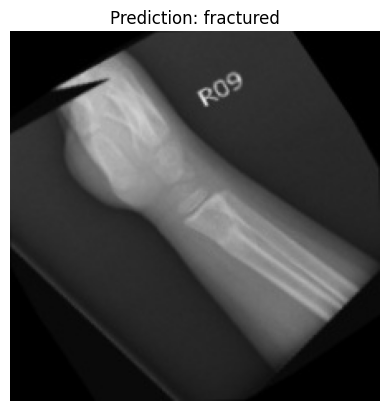

In [67]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(cv2.imread(img_path),cv2.COLOR_BGR2RGB))
plt.title("Prediction: " + train_dataset.classes[pred.item()])
plt.axis("off")

Image Path: dataset/train/fractured/2-rotated1-rotated1-rotated1 - Copy (1).jpg
Actual Label: fractured
Predicted Label: fractured


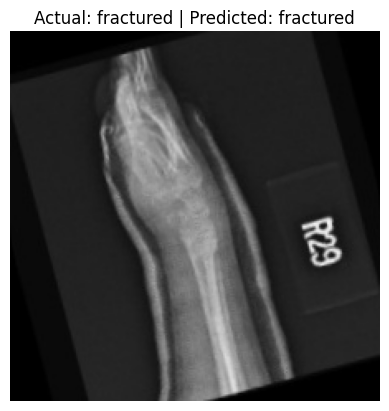

In [68]:
import os
import random
import cv2
import torch
import matplotlib.pyplot as plt

# collect all image paths
image_paths = []

for root, dirs, files in os.walk("dataset"):
    for f in files:
        if f.endswith(".jpg") or f.endswith(".png"):
            image_paths.append(os.path.join(root, f))

# pick random image
img_path = random.choice(image_paths)

# actual label
actual_label = img_path.split("/")[-2]

# read image
img = cv2.imread(img_path)
img_resized = cv2.resize(img,(224,224))

# convert to tensor
tensor_img = torch.tensor(img_resized).permute(2,0,1).float()/255
tensor_img = tensor_img.unsqueeze(0).to(device)

# prediction
model.eval()
with torch.no_grad():
    output = model(tensor_img)
    pred = torch.argmax(output,1)

pred_label = train_dataset.classes[pred.item()]

# show image
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title(f"Actual: {actual_label} | Predicted: {pred_label}")
plt.axis("off")

print("Image Path:", img_path)
print("Actual Label:", actual_label)
print("Predicted Label:", pred_label)

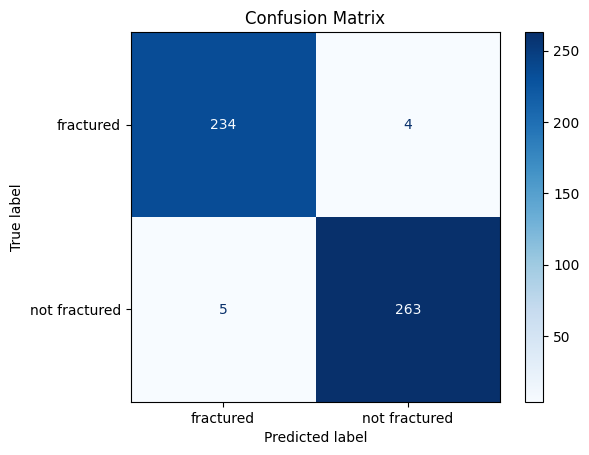

In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_dataloader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

# confusion matrix
cm = confusion_matrix(y_true,y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [70]:
from sklearn.metrics import classification_report

print(classification_report(y_true,y_pred,target_names=train_dataset.classes))

               precision    recall  f1-score   support

    fractured       0.98      0.98      0.98       238
not fractured       0.99      0.98      0.98       268

     accuracy                           0.98       506
    macro avg       0.98      0.98      0.98       506
 weighted avg       0.98      0.98      0.98       506



In [82]:
def showComparision(images, yTrue, yPred):
    cols = 3
    rows = int(len(images) / cols)

    fig, ax = plt.subplots(rows, cols, figsize = (50, 200))
    fig.subplots_adjust(hspace=.5, wspace=.2)  # Adjust spacing between subplots

    for idx, image in enumerate(images):
        yActual = int(yTrue[idx])
        yPredicted = int(yPred[idx])

        yActualStr = test_dataset.classes[yActual]
        yPredictedStr = test_dataset.classes[yPredicted]

        correctPrediction = (yActual == yPredicted)
        color = 'green' if correctPrediction else 'red'

        i = int(idx / cols)
        j = int(idx % cols)

        # Normalize pixel values to range [0, 1]
        image = image.cpu().view(-1, imgSize, imgSize).permute(1, 2, 0)
        image = image.numpy()  # Convert tensor to NumPy array
        image = (image - np.min(image)) / (np.max(image) - np.min(image))  # Normalize

        # Add padding to the image
        pad = 0.1
        ax[i][j].imshow(image, aspect='auto')
        ax[i][j].set_title(f'Actual: {yActualStr} | Predicted: {yPredictedStr}', fontsize = 40, color = color, y = 1.05)
        ax[i][j].axis('off')

        border = Rectangle((0, 0), image.shape[1]-1, image.shape[0]-1, linewidth=5, edgecolor=color, facecolor='none')
        ax[i][j].add_patch(border)


In [86]:
#vision transformer
def makeTheNet(k = 3, s = 1, p = 2):
    class CnnNet(nn.Module):
        def __init__(self):
            super().__init__()

            imgSize = IMAGE_SIZE

            self.conv1 = nn.Conv2d(3, 128, k, s, p)
            self.bnorm1 = nn.BatchNorm2d(128)

            imgSize = ((imgSize - k + 2*p) // s) + 1
            imgSize = imgSize // k

            self.conv2 = nn.Conv2d(128, 256, k, s, p)
            self.bnorm2 = nn.BatchNorm2d(256)

            imgSize = ((imgSize - k + 2*p) // s) + 1
            imgSize = imgSize // k

            self.conv3 = nn.Conv2d(256, 256, k, s, p)
            self.bnorm3 = nn.BatchNorm2d(256)

            imgSize = ((imgSize - k + 2*p) // s) + 1
            imgSize = imgSize // k

            self.fc1 = nn.Linear(imgSize * imgSize * 256, 256)
            self.fc2 = nn.Linear(256, 256)
            self.fc3 = nn.Linear(256, 256)
            self.fc4 = nn.Linear(256, 256)
            self.output = nn.Linear(256, 1)

        def forward(self, x):
            x = F.max_pool2d( self.conv1(x), k)
            x = F.leaky_relu( self.bnorm1(x) )

            x = F.max_pool2d( self.conv2(x), k)
            x = F.leaky_relu( self.bnorm2(x) )

            x = F.max_pool2d( self.conv3(x), k)
            x = F.leaky_relu( self.bnorm3(x) )

            nUnits = x.shape.numel()/x.shape[0]
            x = x.view(-1,int(nUnits))

            x = F.leaky_relu( self.fc1(x) )
            x = F.dropout2d(x, .5)

            x = F.leaky_relu( self.fc2(x) )
            x = F.dropout2d(x, .5)

            x = F.leaky_relu( self.fc3(x) )
            x = F.dropout2d(x, .5)

            x = F.leaky_relu( self.fc4(x) )
            x = F.dropout2d(x, .5)

            return self.output(x)

    net = torchvision.models.vit_b_16(weights = 'DEFAULT')

    for p in net.parameters():
      p.requires_grad = False

    num_features = net.heads.head.in_features  # Get the number of input features to the last layer
    net.heads.head = nn.Linear(num_features, 1)
    lossfun = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(net.parameters(), lr = .001)

    return net, lossfun, optimizer

In [88]:
# swin transformer
def makeTheNet(k=3, s=1, p=2):

    class CnnNet(nn.Module):
        def __init__(self):
            super().__init__()

            imgSize = IMAGE_SIZE

            self.conv1 = nn.Conv2d(3, 128, k, s, p)
            self.bnorm1 = nn.BatchNorm2d(128)

            imgSize = ((imgSize - k + 2*p) // s) + 1
            imgSize = imgSize // k

            self.conv2 = nn.Conv2d(128, 256, k, s, p)
            self.bnorm2 = nn.BatchNorm2d(256)

            imgSize = ((imgSize - k + 2*p) // s) + 1
            imgSize = imgSize // k

            self.conv3 = nn.Conv2d(256, 256, k, s, p)
            self.bnorm3 = nn.BatchNorm2d(256)

            imgSize = ((imgSize - k + 2*p) // s) + 1
            imgSize = imgSize // k

            self.fc1 = nn.Linear(imgSize * imgSize * 256, 256)
            self.fc2 = nn.Linear(256, 256)
            self.fc3 = nn.Linear(256, 256)
            self.fc4 = nn.Linear(256, 256)
            self.output = nn.Linear(256, 1)

        def forward(self, x):

            x = F.max_pool2d(self.conv1(x), k)
            x = F.leaky_relu(self.bnorm1(x))

            x = F.max_pool2d(self.conv2(x), k)
            x = F.leaky_relu(self.bnorm2(x))

            x = F.max_pool2d(self.conv3(x), k)
            x = F.leaky_relu(self.bnorm3(x))

            nUnits = x.shape.numel() / x.shape[0]
            x = x.view(-1, int(nUnits))

            x = F.leaky_relu(self.fc1(x))
            x = F.dropout2d(x, .5)

            x = F.leaky_relu(self.fc2(x))
            x = F.dropout2d(x, .5)

            x = F.leaky_relu(self.fc3(x))
            x = F.dropout2d(x, .5)

            x = F.leaky_relu(self.fc4(x))
            x = F.dropout2d(x, .5)

            return self.output(x)

    net = torchvision.models.swin_b(weights='DEFAULT')

    for p in net.parameters():
        p.requires_grad = False

    num_features = net.head.in_features

    net.head = nn.Linear(num_features, 1)

    lossfun = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(net.parameters(), lr=.001)

    return net, lossfun, optimizer

In [89]:
# wide resnet
def makeTheNet(k=3, s=1, p=2):

    class CnnNet(nn.Module):
        def __init__(self):
            super().__init__()

            imgSize = IMAGE_SIZE

            self.conv1 = nn.Conv2d(3, 128, k, s, p)
            self.bnorm1 = nn.BatchNorm2d(128)

            imgSize = ((imgSize - k + 2*p) // s) + 1
            imgSize = imgSize // k

            self.conv2 = nn.Conv2d(128, 256, k, s, p)
            self.bnorm2 = nn.BatchNorm2d(256)

            imgSize = ((imgSize - k + 2*p) // s) + 1
            imgSize = imgSize // k

            self.conv3 = nn.Conv2d(256, 256, k, s, p)
            self.bnorm3 = nn.BatchNorm2d(256)

            imgSize = ((imgSize - k + 2*p) // s) + 1
            imgSize = imgSize // k

            self.fc1 = nn.Linear(imgSize * imgSize * 256, 256)
            self.fc2 = nn.Linear(256, 256)
            self.fc3 = nn.Linear(256, 256)
            self.fc4 = nn.Linear(256, 256)
            self.output = nn.Linear(256, 1)

        def forward(self, x):

            x = F.max_pool2d(self.conv1(x), k)
            x = F.leaky_relu(self.bnorm1(x))

            x = F.max_pool2d(self.conv2(x), k)
            x = F.leaky_relu(self.bnorm2(x))

            x = F.max_pool2d(self.conv3(x), k)
            x = F.leaky_relu(self.bnorm3(x))

            nUnits = x.shape.numel() / x.shape[0]
            x = x.view(-1, int(nUnits))

            x = F.leaky_relu(self.fc1(x))
            x = F.dropout2d(x, .5)

            x = F.leaky_relu(self.fc2(x))
            x = F.dropout2d(x, .5)

            x = F.leaky_relu(self.fc3(x))
            x = F.dropout2d(x, .5)

            x = F.leaky_relu(self.fc4(x))
            x = F.dropout2d(x, .5)

            return self.output(x)

    net = torchvision.models.wide_resnet101_2(weights='DEFAULT')

    for p in net.parameters():
        p.requires_grad = False

    num_features = net.fc.in_features
    net.fc = nn.Linear(num_features, 1)

    lossfun = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(net.parameters(), lr=.001)

    return net, lossfun, optimizer

In [94]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [101]:
import os
print(os.listdir())

['.config', 'dataset.zip', 'fracture_model.pth', 'dataset', 'sample_data']


In [102]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    root="dataset",
    transform=transform
)

In [103]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

In [105]:
net, lossfun, optimizer = makeTheNet()
net.to(device)
x, y = x.to(device), y.to(device, dtype = torch.float)
yHat = net(x)
yHat = yHat.squeeze()
lossfun(yHat, y)

tensor(0.7208, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

In [106]:
import torch
import numpy as np
from tqdm import tqdm

def function2TrainModel():
    epochs = 30  # Adjust epochs as needed

    net, lossfun, optimizer = makeTheNet()  # Assume this is a predefined function that sets up the model
    net.to(device)

    trainAcc = []
    devAcc = []
    trainLoss = []
    devLoss = []

    best_acc = 0  # Initialize best accuracy
    best_model = None  # To store the best model

    for epochi in tqdm(range(epochs)):

        net.train()
        batchAcc = []
        batchLoss = []

        for X, y in train_dataloader:
            X, y = X.to(device), y.to(device, dtype=torch.float)
            yHat = net(X)
            yHat = yHat.squeeze()
            yHat, y = yHat.cpu(), y.cpu()
            loss = lossfun(yHat, y)
            batchAcc.append(torch.mean(((yHat > .0) == y).float()) * 100)
            batchLoss.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        trainAcc.append(np.mean(batchAcc))
        trainLoss.append(np.mean(batchLoss))

        net.eval()
        with torch.no_grad():
            batchLoss = []
            batchAcc = []

            for X, y in dev_dataloader:
                X, y = X.to(device), y.to(device, dtype=torch.float)
                yHat = net(X)
                yHat = yHat.squeeze()
                yHat, y = yHat.cpu(), y.cpu()
                loss = lossfun(yHat, y)

                batchAcc.append(torch.mean(((yHat > .0) == y).float()) * 100)
                batchLoss.append(loss.item())

            devAcc.append(np.mean(batchAcc))
            devLoss.append(np.mean(batchLoss))

            # Check if current epoch's accuracy is the best
            if devAcc[-1] > best_acc:
                best_acc = devAcc[-1]
                best_model = net.state_dict()  # Save the best model state

    # Optionally, load the best model state back into the model
    net.load_state_dict(best_model)

    return trainAcc, devAcc, trainLoss, devLoss, net

In [107]:
import random

# Setting seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

In [110]:
trainAcc, devAcc, trainLoss, devLoss, net = function2TrainModel()

100%|██████████| 30/30 [1:19:44<00:00, 159.48s/it]


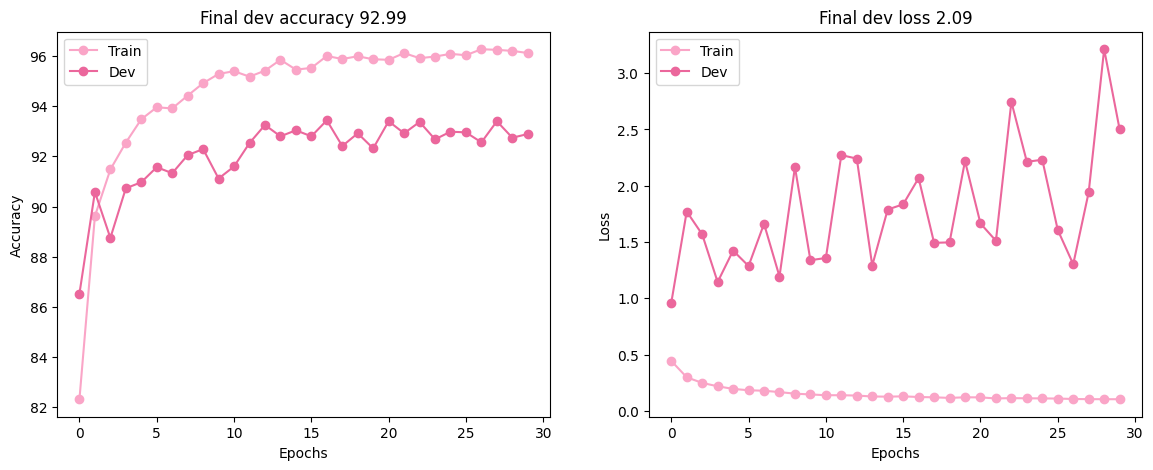

In [111]:
fig, ax = plt.subplots(1,2,figsize=(14,5))
ax[0].plot(trainAcc, 'o-', label='Train')
ax[0].plot(devAcc, 'o-', label='Dev')
ax[0].legend()
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].set_title(f'Final dev accuracy {np.mean(devAcc[-10:]):.2f}')

ax[1].plot(trainLoss, 'o-', label='Train')
ax[1].plot(devLoss, 'o-', label='Dev')
ax[1].legend()
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].set_title(f'Final dev loss {np.mean(devLoss[-10:]):.2f}')

plt.show()

In [112]:
net.eval()

images = []
yTrue, yPred = [], []

with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device, dtype=torch.float)
        yHat = net(X)
        yHat = yHat.squeeze()
        yHat, y = yHat.cpu(), y.cpu()

        images.extend(X)
        yTrue.extend(y)
        yPred.extend((yHat > .0).float())

In [113]:
yTrue, yPred = [yItem.item() for yItem in yTrue], [yItem.item() for yItem in yPred]

In [114]:
def showComparision(images, yTrue, yPred):
    cols = 3
    rows = int(len(images) / cols)

    fig, ax = plt.subplots(rows, cols, figsize = (50, 200))
    fig.subplots_adjust(hspace=.5, wspace=.2)  # Adjust spacing between subplots

    for idx, image in enumerate(images):
        yActual = int(yTrue[idx])
        yPredicted = int(yPred[idx])

        yActualStr = test_dataset.classes[yActual]
        yPredictedStr = test_dataset.classes[yPredicted]

        correctPrediction = (yActual == yPredicted)
        color = 'green' if correctPrediction else 'red'

        i = int(idx / cols)
        j = int(idx % cols)

        # Normalize pixel values to range [0, 1]
        image = image.cpu().view(-1, imgSize, imgSize).permute(1, 2, 0)
        image = image.numpy()  # Convert tensor to NumPy array
        image = (image - np.min(image)) / (np.max(image) - np.min(image))  # Normalize

        # Add padding to the image
        pad = 0.1
        ax[i][j].imshow(image, aspect='auto')
        ax[i][j].set_title(f'Actual: {yActualStr} | Predicted: {yPredictedStr}', fontsize = 40, color = color, y = 1.05)
        ax[i][j].axis('off')

        border = Rectangle((0, 0), image.shape[1]-1, image.shape[0]-1, linewidth=5, edgecolor=color, facecolor='none')
        ax[i][j].add_patch(border)

In [116]:
imgSize = 224

def showComparision(images, yTrue, yPred):

    for i in range(len(images)):

        image = images[i]

        image = image.cpu().view(-1, imgSize, imgSize).permute(1,2,0)

        image = image.numpy()

        image = (image - np.min(image)) / (np.max(image) - np.min(image))

        plt.imshow(image)
        plt.title(f"True: {yTrue[i]} | Pred: {yPred[i]}")
        plt.axis("off")
        plt.show()

In [118]:
class_names = train_dataset.classes

def showComparision(images, yTrue, yPred):

    for i in range(len(images)):

        image = images[i].cpu().permute(1,2,0).numpy()

        true_label = class_names[int(yTrue[i])]
        pred_label = class_names[int(yPred[i])]

        plt.imshow(image)
        plt.title(f"True: {true_label} | Pred: {pred_label}")
        plt.axis("off")
        plt.show()

In [120]:
class_names = train_dataset.classes

def showComparision(images, yTrue, yPred):

    plt.figure(figsize=(15,10))

    for i in range(len(images)):

        image = images[i].cpu().permute(1,2,0).numpy()

        true_label = class_names[int(yTrue[i])]
        pred_label = class_names[int(yPred[i])]

        plt.subplot(3,11,i+1)
        plt.imshow(image)
        plt.axis("off")

        # color based on correctness
        if true_label == pred_label:
            color = "green"
        else:
            color = "red"

        plt.title(f"Actual: {true_label} | Predicted: {pred_label}", color=color)

        # border color
        ax = plt.gca()
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

    plt.tight_layout()
    plt.show()

In [123]:
class_names = train_dataset.classes

def showComparision(images, yTrue, yPred):

    cols = 6
    rows = (len(images)+cols-1)//cols

    plt.figure(figsize=(15,8))

    for i in range(len(images)):

        image = images[i].cpu().permute(1,2,0).numpy()

        image = (image - image.min())/(image.max()-image.min())

        true_label = class_names[int(yTrue[i])]
        pred_label = class_names[int(yPred[i])]

        plt.subplot(rows,cols,i+1)
        plt.imshow(image)
        plt.axis("off")

        color = "green" if true_label==pred_label else "red"

        plt.title(f"A:{true_label} | P:{pred_label}",color=color)

    plt.tight_layout()
    plt.show()

In [124]:
train_dataset = datasets.ImageFolder(
    root="dataset/train",
    transform=transform
)

In [125]:
val_dataset = datasets.ImageFolder(
    root="dataset/val",
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root="dataset/test",
    transform=transform
)

In [126]:
class_names = train_dataset.classes

def showComparision(images, yTrue, yPred):

    cols = 6
    rows = (len(images)+cols-1)//cols

    plt.figure(figsize=(15,8))

    for i in range(len(images)):

        image = images[i].cpu().permute(1,2,0).numpy()

        image = (image - image.min())/(image.max()-image.min())

        true_label = class_names[int(yTrue[i])]
        pred_label = class_names[int(yPred[i])]

        plt.subplot(rows,cols,i+1)
        plt.imshow(image)
        plt.axis("off")

        color = "green" if true_label==pred_label else "red"

        plt.title(f"A:{true_label} | P:{pred_label}",color=color)

    plt.tight_layout()
    plt.show()

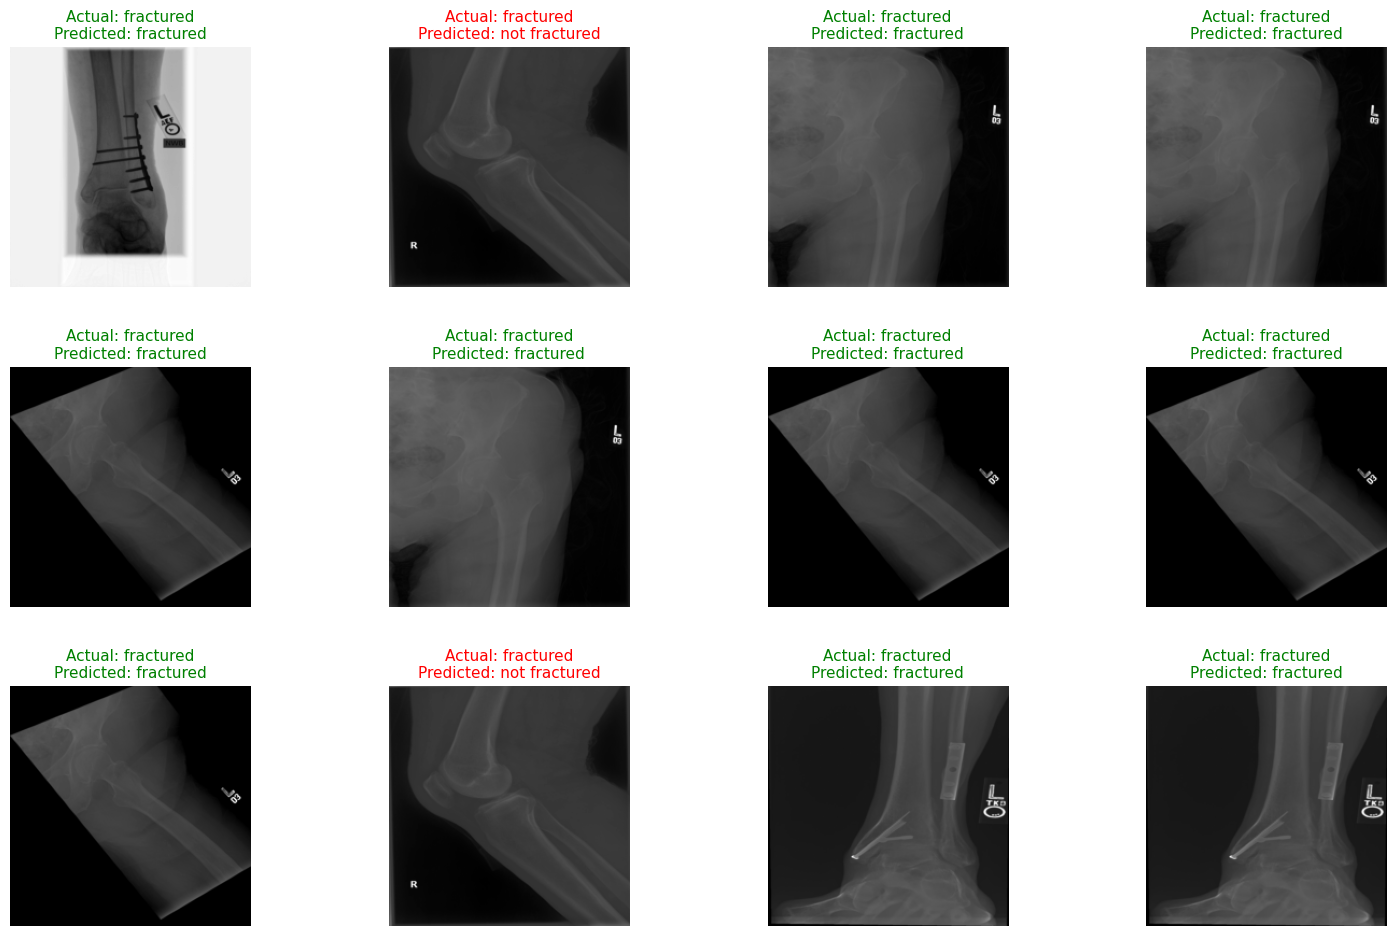

In [129]:
visualizableCount = 12

visualizableImages = images[:visualizableCount]
visualizableTrue = yTrue[:visualizableCount]
visualizablePred = yPred[:visualizableCount]

class_names = train_dataset.classes

cols = 4
rows = (visualizableCount + cols - 1) // cols

plt.figure(figsize=(16,10))

for i in range(visualizableCount):

    image = visualizableImages[i].cpu().permute(1,2,0).numpy()
    image = (image - image.min()) / (image.max() - image.min())

    true_label = class_names[int(visualizableTrue[i])]
    pred_label = class_names[int(visualizablePred[i])]

    plt.subplot(rows, cols, i+1)
    plt.imshow(image)
    plt.axis("off")

    color = "green" if true_label == pred_label else "red"

    plt.title(f"Actual: {true_label}\nPredicted: {pred_label}", color=color, fontsize=11)

plt.tight_layout(pad=3)
plt.show()